In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h3

In [141]:
#load data
df = pd.read_csv("data/Crimes_-_2020_to_Present_2026.csv")
df_original = df.copy()
df = df.sample(200000, random_state=42)
print(df.head())
print(df.shape)
df.info
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

               ID Case Number                    Date  \
1284582  12225832    JD436741  11/20/2020 09:30:00 AM   
725592   13067216    JG253702  05/09/2023 10:30:00 AM   
706618   13096042    JG287985  06/03/2023 10:00:00 PM   
610170   13236176    JG454797  10/07/2023 03:55:00 PM   
1396216  12058063    JD240856  05/23/2020 09:35:00 AM   

                                       Block  IUCR             Primary Type  \
1284582                      008XX E 53RD ST  0820                    THEFT   
725592   078XX S DR MARTIN LUTHER KING JR DR  0820                    THEFT   
706618                       007XX E 92ND PL  0291  CRIMINAL SEXUAL ASSAULT   
610170                   006XX W MONTROSE DR  0820                    THEFT   
1396216                    069XX S MORGAN ST  051A                  ASSAULT   

                    Description Location Description  Arrest  Domestic  ...  \
1284582          $500 AND UNDER            RESIDENCE   False     False  ...   
725592           $500 AN

In [142]:
#Basic Data Cleaning
print(df.isnull().sum())
df = df.dropna(subset=['Latitude', 'Longitude'])
df['Date'] = pd.to_datetime(df['Date'])
df_original['Date'] = pd.to_datetime(df_original['Date'], errors='coerce')
df_original = df_original.dropna(subset=['Date'])

ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description    1084
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       3
Community Area            17
FBI Code                   0
X Coordinate            2977
Y Coordinate            2977
Year                       0
Updated On                 0
Latitude                2977
Longitude               2977
Location                2977
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_28752\2766276247.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_original['Date'] = pd.to_datetime(df_original['Date'], errors='coerce')


In [133]:
# Correct features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day      # ✅ correct (1–31)
df['DayOfWeek'] = df['Date'].dt.dayofweek  # ✅ ML feature
df['Hour'] = df['Date'].dt.hour

df['Date'] = pd.to_datetime({
    'year': df['Year'],
    'month': df['Month'],
    'day': df['Day']
})
df = df[['Primary Type','Latitude','Longitude',
         'Year','Month','Day','DayOfWeek','Hour',
         'Arrest','Domestic']]

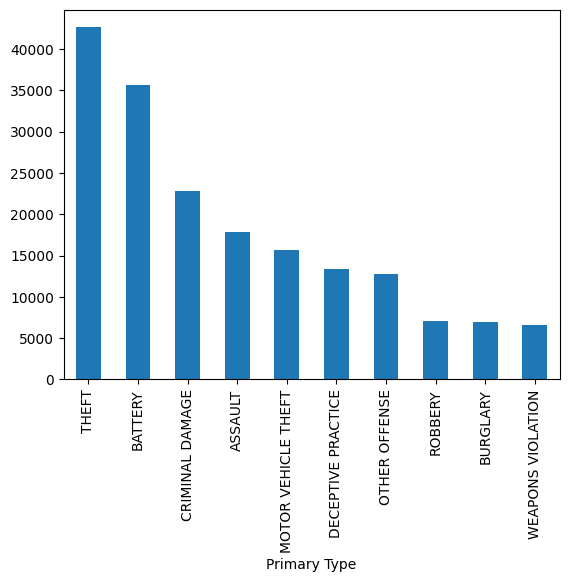

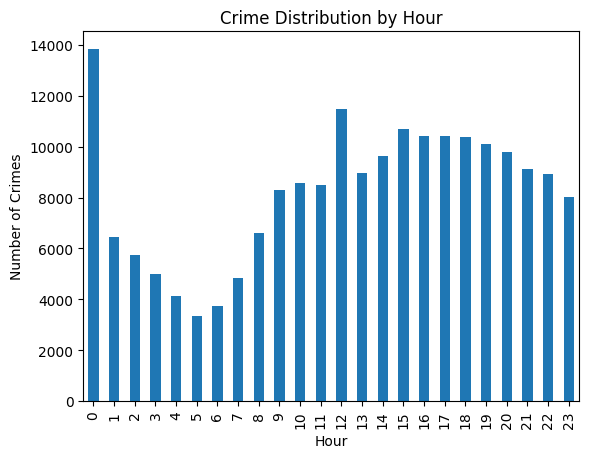

In [134]:
#Quick Visualization
import matplotlib.pyplot as plt

df['Primary Type'].value_counts().head(10).plot(kind='bar')
plt.show()

df['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Crime Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Crimes")
plt.show()

In [135]:
# H3 Spatial Indexing 
# [(lat, lon) → area (hexagon)]

df['h3_cell'] = df.apply(
    lambda x: h3.latlng_to_cell(x['Latitude'], x['Longitude'], 7),
    axis=1
)

df[['Latitude', 'Longitude', 'h3_cell']].head()

,Latitude,Longitude,h3_cell
1284582,41.798627,-87.605656,872664cc4ffffff
725592,41.752019,-87.614978,872664cceffffff
706618,41.726595,-87.606103,872664ccaffffff
610170,41.962034,-87.645899,872664d89ffffff
1396216,41.768310,-87.649346,872664cc2ffffff


In [136]:
# Create Hotspot Dataset

grouped = df.groupby(['h3_cell', 'Hour']).size().reset_index(name='crime_count')
grouped.head()

#Create Target
grouped['target'] = (grouped['crime_count'] > 2).astype(int) 

In [137]:
#Train XGBoost Model
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X = grouped[['Hour']]
y = grouped['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9433681073025335


In [138]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

heat_data = df[['Latitude', 'Longitude']].values.tolist()

HeatMap(heat_data).add_to(m)

m.save("heatmap.html")

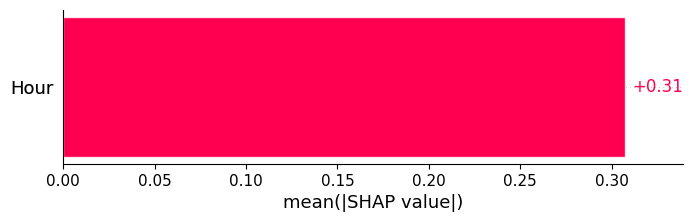

In [139]:
import shap

# Create explainer
explainer = shap.Explainer(model)

# Use small sample (important!)
X_sample = X_test.sample(min(1000, len(X_test)))

shap_values = explainer(X_sample)

# Plot feature importance
shap.plots.bar(shap_values)

22:40:10 - cmdstanpy - INFO - Chain [1] start processing
22:40:11 - cmdstanpy - INFO - Chain [1] done processing


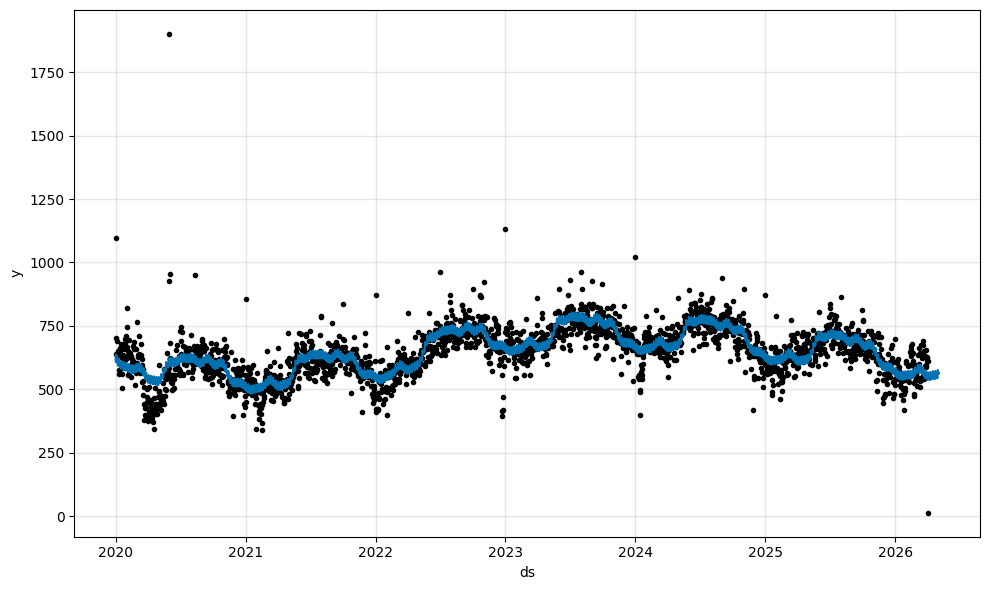

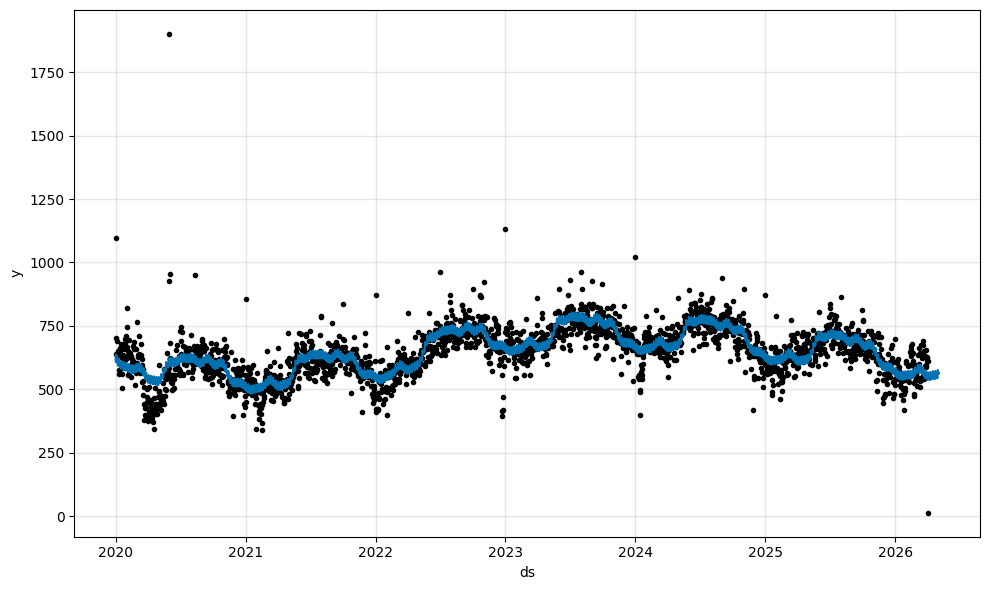

In [143]:
from prophet import Prophet

# Prepare time series
df_small = df.sample(100000, random_state=42)
ts = df_original.groupby(df_original['Date'].dt.date).size().reset_index(name='y')
ts.columns = ['ds', 'y']
# Train model
model_p = Prophet(uncertainty_samples=0)
model_p.fit(ts)

# Predict future
future = model_p.make_future_dataframe(periods=30)
forecast = model_p.predict(future)

# Plot
model_p.plot(forecast)